In [33]:
import torch
from utils import *
import matplotlib.pyplot as plt

In [34]:
def print_stylegan_results(w2_values, w2_baseline, avg_log_reward, diversity, diversity_trace_cov, male_fraction, prior_male):

    # --- stats ---
    w2_stats = compute_stats(w2_values)
    alr_stats = compute_stats(avg_log_reward)
    div_stats = compute_stats(diversity)
    div_cov_stats = compute_stats(diversity_trace_cov)
    male_stats = compute_stats(male_fraction)

    # --- ttests ---
    w2_tests = compute_ttest(w2_values, w2_baseline, pairwise=False)

    samplers_only = ['ULA', 'MALA', 'G_MH']
    alr_tests = compute_ttest({k: avg_log_reward[k] for k in samplers_only}, avg_log_reward['RS'], pairwise=False)
    div_tests = compute_ttest({k: diversity[k] for k in samplers_only}, diversity['RS'], pairwise=False)
    div_cov_tests = compute_ttest({k: diversity_trace_cov[k] for k in samplers_only}, diversity_trace_cov['RS'], pairwise=False)
    male_tests = compute_ttest({k: male_fraction[k] for k in samplers_only}, male_fraction['RS'], pairwise=False)

    # --- Table 1: W2 ---
    print(f"\n{'='*60}")
    print(f"Table 1: W2 Evaluation (StyleGAN2)")
    print(f"{'='*60}")
    print(f"{'Sampler':<10} {'W2 mean±std':<20} {'t':^8} {'p':^8} {'Sig':^6}")
    print("-" * 60)

    print(f"{'RS':<10} {np.mean(w2_baseline):.2f}±{np.std(w2_baseline, ddof=1):.2f}{'':^8} {'—':^8} {'—':^8} {'—':^6}")

    for name in samplers_only:
        t = w2_tests[f'{name} vs RS']['t']
        p = w2_tests[f'{name} vs RS']['p-value']
        s = w2_tests[f'{name} vs RS']['significant']
        print(f"{name:<10} {w2_stats[name]['mean']:.2f}±{w2_stats[name]['std']:.2f}{'':^8} {t:^8.3f} {p:^8.3f} {s:^6}")
    print("-" * 60)

    # --- Table 2: Qualitative Metrics ---
    print(f"\n{'='*130}")
    print(f"Table 2: Qualitative Metrics (StyleGAN2)")
    print(f"{'='*130}")
    print(f"{'Sampler':<10} {'AvgLogR':^14} {'p':^10} {'Diversity(all-pairs)':^14} {'p':^8} {'TraceCov':^14} {'p':^8} {'Male%':^12} {'p':^6}")
    print("-" * 130)

    print(f"{'Prior':<10} {'—':^14} {'—':^8} {'—':^14} {'—':^8} {'—':^14} {'—':^8} "
          f"{np.mean(prior_male):.3f}±{np.std(prior_male):.3f}{'':^2} {'—':^6}")

    print(f"{'RS':<10} {alr_stats['RS']['mean']:.2f}±{alr_stats['RS']['std']:.2f}{'':^6} {'—':^8} "
          f"{div_stats['RS']['mean']:.1f}±{div_stats['RS']['std']:.1f}{'':^6} {'—':^8} "
          f"{div_cov_stats['RS']['mean']:.1f}±{div_cov_stats['RS']['std']:.1f}{'':^6} {'—':^8} "
          f"{male_stats['RS']['mean']:.3f}±{male_stats['RS']['std']:.3f}{'':^2} {'—':^6}")

    for name in samplers_only:
        ap = alr_tests[f'{name} vs RS']['p-value']
        dp = div_tests[f'{name} vs RS']['p-value']
        dcp = div_cov_tests[f'{name} vs RS']['p-value']
        mp = male_tests[f'{name} vs RS']['p-value']
        print(f"{name:<10} {alr_stats[name]['mean']:.2f}±{alr_stats[name]['std']:.2f}{'':^6} {ap:^8.3f} "
              f"{div_stats[name]['mean']:.1f}±{div_stats[name]['std']:.1f}{'':^6} {dp:^8.3f} "
              f"{div_cov_stats[name]['mean']:.1f}±{div_cov_stats[name]['std']:.1f}{'':^6} {dcp:^8.3f} "
              f"{male_stats[name]['mean']:.3f}±{male_stats[name]['std']:.3f}{'':^2} {mp:^6.3f}")
    print("-" * 130)

In [35]:
def show_stylegan_samples(samples_dict, avg_log_reward, diversity, trial_to_show, model, clf, n_show=10, max_per_row=10):

    sampler_keys = ['RS', 'ULA', 'MALA', 'G_MH']
    sampler_titles = ['RS', 'ULA', 'MALA', 'Gaussian MH']

    for key, title in zip(sampler_keys, sampler_titles):
        viz = samples_dict[key]

        with torch.no_grad():
            imgs = ((model(viz[:n_show]) + 1) / 2).clamp(0, 1)
            probs = torch.sigmoid(clf(model(viz[:n_show]))).squeeze().cpu().numpy()

        n_rows = (n_show + max_per_row - 1) // max_per_row  # ceil division
        fig, axes = plt.subplots(n_rows, max_per_row, figsize=(1.5 * max_per_row, 1.5 * n_rows))

        # normalize axes to always be 2D, even if n_rows==1
        if n_rows == 1:
            axes = axes.reshape(1, -1)

        for i in range(n_rows * max_per_row):
            row, col = divmod(i, max_per_row)
            ax = axes[row, col]
            if i < n_show:
                ax.imshow(imgs[i].permute(1, 2, 0).detach().cpu())
                color = 'green' if probs[i] > 0.7 else 'red' if probs[i] < 0.3 else 'orange'
                ax.set_title(f'{probs[i]:.2f}', fontsize=8, color=color)
            ax.axis('off')

        alr = avg_log_reward[key][trial_to_show]
        div = diversity[key][trial_to_show]

        plt.suptitle(f"{title} | ALR={alr:.2f}, Div={div:.1f}", fontsize=10)
        plt.subplots_adjust(top=0.88, wspace=0.05, hspace=0.3)
        plt.show()

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('stylegan2-ada-pytorch'))

from models import StyleGAN2Wrapper
import pickle

# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 'cpu'
print(f'device being used: {device}')
with open('stylegan2-ada-pytorch/stylegan2_celeba.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)

stylegan = StyleGAN2Wrapper(G).to(device)
stylegan.eval()

z = torch.randn(100, 512).to(device)
imgs = stylegan(z)
imgs = (imgs + 1) / 2



device being used: cpu


In [20]:
imgs.shape

torch.Size([20, 3, 256, 256])

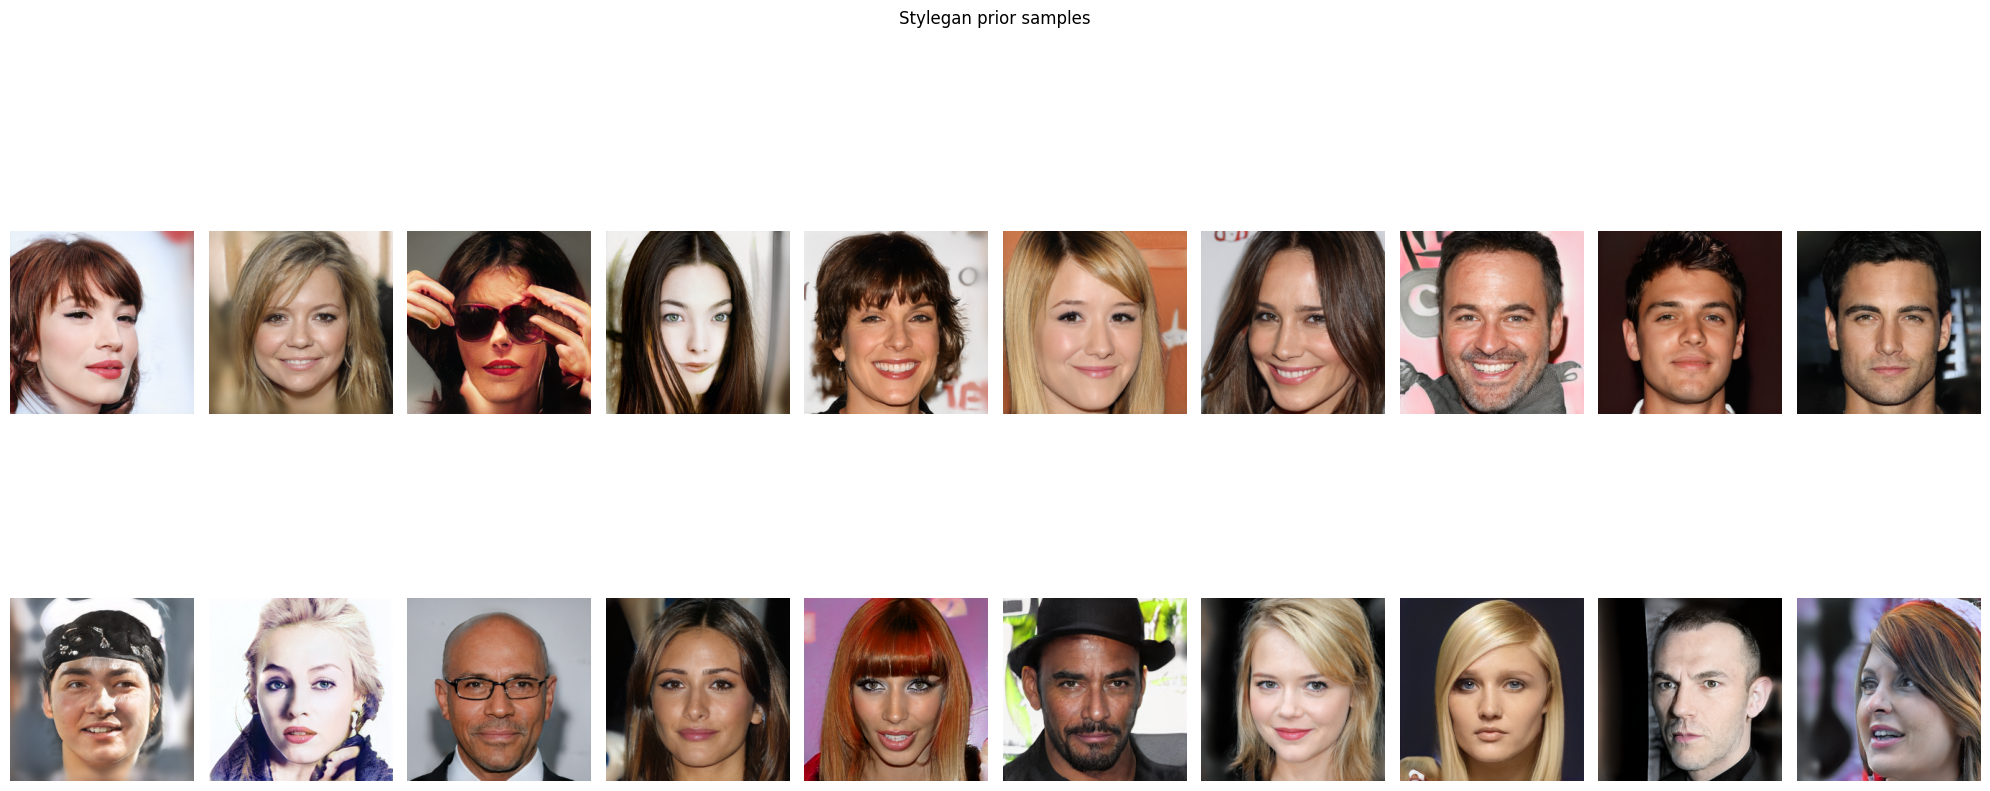

In [21]:
import matplotlib.pyplot as plt

imgs_clamped = imgs.clamp(0, 1)
fig, axes = plt.subplots(2, 10, figsize=(20, 10))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(imgs_clamped[i].permute(1, 2, 0).detach().cpu())
    axes[row, col].axis('off')

plt.suptitle('Stylegan prior samples')
plt.tight_layout()
plt.show()

In [8]:
# load clf
from models import classifier

smile_clf = classifier().to(device)
smile_clf.load_state_dict(torch.load('clf_checkpoints/smile_clf_aug.pth', map_location=device, weights_only=False))
smile_clf.eval()

male_clf = classifier().to(device)
male_clf.load_state_dict(torch.load('clf_checkpoints/male_clf_aug.pth', map_location=device, weights_only=False))
male_clf.eval()

classifier(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc): Linear(in_features=65536, out_features=1, bias=True)
)

In [9]:
#def print_stylegan_results(w2_values, w2_baseline, avg_log_reward, diversity, diversity_trace_cov, male_fraction, prior_male):
#def show_stylegan_samples(samples_dict, avg_log_reward, diversity, trial_to_show, model, clf, n_show=10):
r = torch.load('results_stylegan.pt', weights_only=False, map_location=device)
r['stylegan'].keys()
prior_male = torch.load('prior_male_results.pt', weights_only=False)['prior_male']
diversity_all_pairs = torch.load('diversity_all_pairs_results.pt', weights_only=False)


In [10]:
w2_values = r['stylegan']['w2_values']
w2_baseline = r['stylegan']['w2_baseline']
samples = r['stylegan']['samples']
avg_log_reward = r['stylegan']['avg_log_reward']
diversity = r['stylegan']['diversity']
diversity_trace_cov = r['stylegan']['diversity_trace_cov']
male_fraction = r['stylegan']['male_fraction']

In [11]:
print_stylegan_results(w2_values, w2_baseline, avg_log_reward, diversity_all_pairs, diversity_trace_cov, male_fraction, prior_male)


Table 1: W2 Evaluation (StyleGAN2)
Sampler    W2 mean±std             t        p      Sig  
------------------------------------------------------------
RS         29.71±0.02            —        —       —   
ULA        29.77±0.01          6.050    0.004    Yes  
MALA       29.73±0.02          1.598    0.185     No  
G_MH       29.30±0.59          -1.559   0.194     No  
------------------------------------------------------------

Table 2: Qualitative Metrics (StyleGAN2)
Sampler       AvgLogR         p      Diversity(all-pairs)    p        TraceCov       p        Male%       p   
----------------------------------------------------------------------------------------------------------------------------------
Prior            —           —           —           —           —           —     0.372±0.054     —   
RS         -0.28±0.01          —     318.7±1.5          —     511.9±0.9          —     0.314±0.021     —   
ULA        -0.29±0.01        0.260   319.8±2.3        0.478   514.5±0

In [31]:
import numpy as np
rs = r['stylegan']['w2_baseline']
ula = r['stylegan']['w2_values']['ULA']
diffs = [u - s for u, s in zip(ula, rs)]
print([f'{x:.4f}' for x in rs])
print([f'{x:.4f}' for x in ula])
print([f'{d:.4f}' for d in diffs])


d_bar = np.mean(diffs)
s_d = np.std(diffs, ddof=1)
print(f"d̄ = {d_bar:.4f}")
print(f"s_d = {s_d:.4f}")
#t = d̄ / (s_d/sqrt(n))

['29.6708', '29.7205', '29.7125', '29.7303', '29.7150']
['29.7655', '29.7758', '29.7748', '29.7838', '29.7488']
['0.0947', '0.0553', '0.0623', '0.0535', '0.0338']
d̄ = 0.0599
s_d = 0.0221


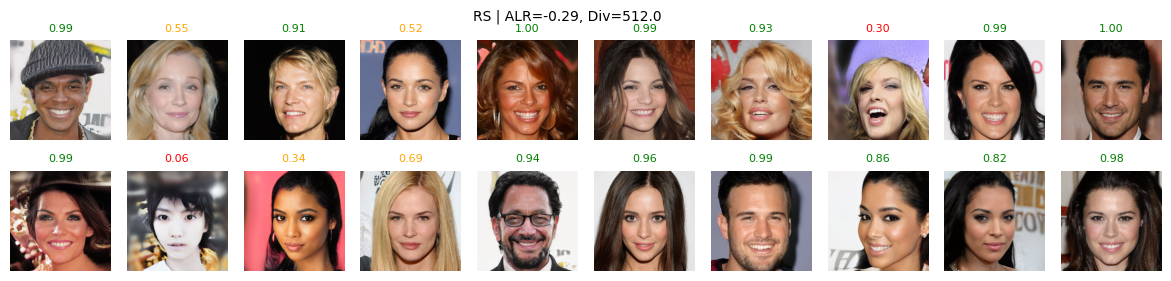

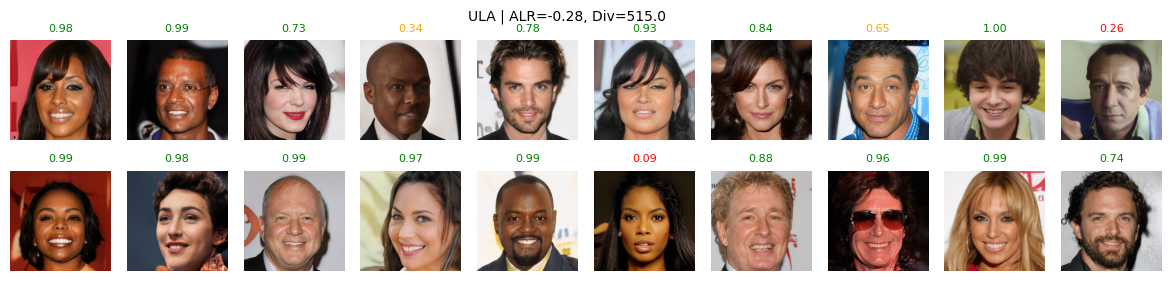

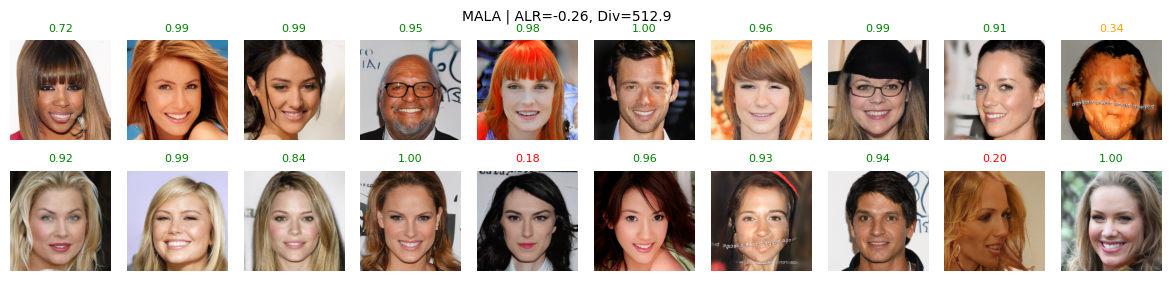

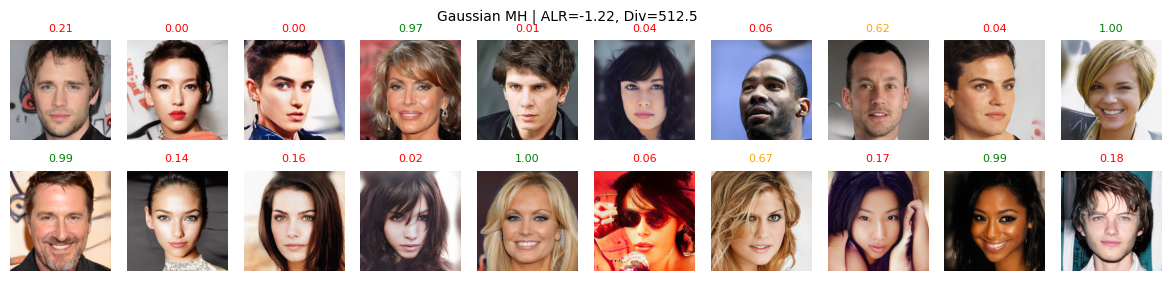

In [18]:
trial_idx = 2

samples_trial3 = {
    'RS': samples['RS'][trial_idx],
    'ULA': samples['ULA'][trial_idx],
    'MALA': samples['MALA'][trial_idx],
    'G_MH': samples['G_MH'][trial_idx],
}

show_stylegan_samples(
    samples_trial3,
    avg_log_reward,
    diversity_trace_cov,
    trial_to_show=trial_idx,
    model=stylegan,
    clf=smile_clf,
    n_show=20
)